# C5 forecast for Q1 2026 — Prophet & NeuralProphet

**Part 1 — Prophet:** univariate Prophet on **C5** from the master workbook; forecasts **business days** in the Q1 window.

**Part 2 — NeuralProphet:** same **`df_fit`** (`ds`, `y`) as Part 1; **`freq='B'`**; **`n_forecasts=60`** defines a **60-step** ahead horizon (first business days after `TRAIN_END`), which can be shorter than full calendar Q1.

**Install (once)** (base stack):  
`pip install prophet pandas openpyxl matplotlib torch`


Suggested **clean stack (Python 3.12)** — uninstall conflicting builds first, then install **torch + torchvision in one step** so versions stay paired (fixes `torchvision::nms`):

```bash
pip uninstall -y neuralprophet pytorch-lightning lightning lightning-utilities torch torchvision torchmetrics torchaudio captum
pip install torch torchvision pytorch-lightning==1.9.5 "neuralprophet==0.8.0"
```

(Optional: `pip install "numpy>=1.25,<2" "pandas>=2,<3"` if you need the NeuralProphet pins.) If **torchaudio** was pinned to an old **torch==2.2.x**, remove or upgrade it—otherwise pip reports conflicts even when Part 3 runs.

(CPU-only Torch: add `--index-url https://download.pytorch.org/whl/cpu` for the `pip install torch torchvision ...` line.)

If you see **`RuntimeError: operator torchvision::nms does not exist`**, Torch and torchvision are mismatched — reinstall **both from the same PyTorch wheel index** (same CUDA/CPU line) as in the command above.

**If `pip` fails building NumPy (Meson)** on **Python 3.13**, use **3.11/3.12** instead (same numpy&lt;2 note as above).

Outputs next to this notebook / `BASE_DIR`:

- Prophet: `prophet_c5_q1_2026_forecast.csv`, … optional vs Q126 comparison files.
- NeuralProphet: `neuralprophet_c5_forecast.csv`, plot, optional vs Q126 comparison files.

In [ ]:
import sys
MOUNT_GOOGLE_DRIVE = True
if "google.colab" in sys.modules and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
elif "google.colab" not in sys.modules:
    print("Local run — skip Drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

# --- knobs ---
BASE_DIR: Path | None = None  # None → cwd if markers exist, else ~/Downloads/Project 005 Data
MASTER_OVERRIDE: str | None = None  # basename or full path to master xlsx
TRAIN_START = "2015-01-01"
TRAIN_END = "2025-12-31"
Q1_START = "2026-01-01"
Q1_END = "2026-03-31"
USE_LOG = False  # True → model log(C5); back-transform yhat for CSV/plot

# Env overrides (same as prophet_c5_q1_2026_forecast.py): PROPHET_MASTER_XLSX, XGBOOST_MASTER_XLSX
OUT_CSV = "prophet_c5_q1_2026_forecast.csv"
OUT_PNG = "prophet_c5_q1_2026_forecast.png"
# Actuals for backtest / score (same layout as Chronos notebooks)
ACTUAL_XLSX = "C5 Through End Q126.xlsx"
ACTUAL_SHEET = "SIN Timeseries - D"
ACTUAL_DATE_COL = "Date"
ACTUAL_C5_COL = "$/Tonne"
COMPARE_OUT_CSV = "prophet_c5_q1_2026_vs_Q126.csv"
COMPARE_OUT_PNG = "prophet_c5_q1_2026_vs_Q126.png"


# --- Part 2: NeuralProphet (same df_fit / business-day freq; horizon = n_forecasts steps) ---
NEURAL_OUT_CSV = "neuralprophet_c5_forecast.csv"
NEURAL_OUT_PNG = "neuralprophet_c5_forecast.png"
NEURAL_COMPARE_OUT_CSV = "neuralprophet_c5_vs_Q126.csv"
NEURAL_COMPARE_OUT_PNG = "neuralprophet_c5_vs_Q126.png"

In [ ]:
def _first_existing(candidates: list[str | None], base: Path) -> Path | None:
    for c in candidates:
        if not c:
            continue
        p = Path(c)
        if p.is_file():
            return p.resolve()
        q = base / c
        if q.is_file():
            return q.resolve()
    return None


def resolve_base_dir(explicit: Path | None) -> Path:
    if explicit and explicit.is_dir():
        return explicit.resolve()
    cwd = Path.cwd()
    markers = (
        "Master_Data_Base_version_Brownian_by_frequency.xlsx",
        "Master_Data_AVG_version_update.xlsx",
    )
    if any((cwd / m).is_file() for m in markers):
        return cwd
    fallback = Path.home() / "Downloads" / "Project 005 Data"
    if fallback.is_dir():
        return fallback
    return cwd


def load_c5_series(base_dir: Path, master_override: str | None) -> tuple[pd.Series, Path]:
    cands = [
        master_override,
        os.environ.get("PROPHET_MASTER_XLSX"),
        os.environ.get("XGBOOST_MASTER_XLSX"),
        "Master_Data_Base_version_Brownian_by_frequency.xlsx",
        "Master_Data_AVG_version_update.xlsx",
    ]
    path = _first_existing(cands, base_dir)
    if path is None:
        raise FileNotFoundError(
            "No master workbook found. Tried: " + ", ".join(str(x) for x in cands if x)
        )
    df = pd.read_excel(path)
    date_col = "Date" if "Date" in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    if "C5" not in df.columns:
        raise KeyError(f"C5 column missing in {path}; columns={list(df.columns)[:20]}...")
    y = pd.to_numeric(df["C5"], errors="coerce")
    s = pd.Series(y.values, index=df[date_col].values)
    s = s.groupby(level=0).last().sort_index()
    s = s[np.isfinite(s.values) & (s.values > 0)]
    return s, path


def build_prophet_df(series: pd.Series, use_log: bool) -> pd.DataFrame:
    out = pd.DataFrame({"ds": series.index, "y": series.values.astype(float)})
    out = out.dropna(subset=["y"])
    if use_log:
        out["y"] = np.log(out["y"])
    return out.sort_values("ds").reset_index(drop=True)


def load_c5_actuals_q126(
    base_dir: Path,
    sheet: str,
    date_col: str,
    c5_col: str,
    basename: str,
) -> tuple[pd.Series, Path]:
    """Daily C5 from Clarksons SIN export (same file as other Project 005 pipelines)."""
    cands = [os.environ.get("PROPHET_ACTUAL_XLSX"), basename, basename.lower()]
    path = _first_existing(cands, base_dir)
    if path is None:
        raise FileNotFoundError(f"Actuals workbook not found. Tried: {basename}")
    last_err: Exception | None = None
    for header in (5, 0):
        try:
            df = pd.read_excel(path, sheet_name=sheet, header=header)
        except Exception as e:
            last_err = e
            continue
        if date_col not in df.columns and len(df.columns) >= 2:
            df = df.rename(columns={df.columns[0]: date_col, df.columns[1]: c5_col})
        if date_col not in df.columns or c5_col not in df.columns:
            continue
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df[c5_col] = pd.to_numeric(df[c5_col], errors="coerce")
        df = df.dropna(subset=[date_col, c5_col])
        s = pd.Series(df[c5_col].values, index=df[date_col].values)
        s = s.groupby(level=0).last().sort_index()
        s = s[np.isfinite(s.values) & (s.values > 0)]
        return s, path
    raise ValueError(f"Could not read {path} sheet={sheet!r}: {last_err}")

In [ ]:
try:
    from prophet import Prophet
except ImportError as e:
    raise ImportError("Install Prophet: pip install prophet") from e

IN_COLAB = "google.colab" in sys.modules
COLAB_DATA_DIR = Path("/content/drive/MyDrive/Project 005 Data")

if IN_COLAB:
    try:
        from google.colab import userdata
        _hf = userdata.get("HF_TOKEN")
        if _hf:
            os.environ["HF_TOKEN"] = _hf
    except Exception:
        pass

BASE_DIR = COLAB_DATA_DIR if IN_COLAB else Path.cwd()
_markers = (
    "Transformed_Deseason_Residual_Browian.xlsx",
    "Transformed_Deseason_Residuals_Lagged.xlsx",
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
    "Master_Data_AVG_version_update_Lagged.xlsx",
    "Master_Data_AVG_version_update.xlsx",
)

base_dir = resolve_base_dir(BASE_DIR)
c5, master_path = load_c5_series(base_dir, MASTER_OVERRIDE)
print(f"BASE_DIR: {base_dir}")
print(f"Master: {master_path}")
print(f"C5 series: {len(c5)} days | {c5.index.min().date()} → {c5.index.max().date()}")

train_end = pd.Timestamp(TRAIN_END)
train_start = pd.Timestamp(TRAIN_START)
train = c5.loc[(c5.index <= train_end) & (c5.index >= train_start)]
if len(train) < 30:
    raise ValueError(f"Training sample too small after train-end filter: n={len(train)}")

df_fit = build_prophet_df(train, use_log=USE_LOG)
print(f"Training rows: {len(df_fit)} | USE_LOG={USE_LOG}")

BASE_DIR: /content/drive/MyDrive/Project 005 Data
Master: /content/drive/MyDrive/Project 005 Data/Master_Data_AVG_version_update.xlsx
C5 series: 5240 days | 2006-01-02 → 2026-01-30
Training rows: 2870 | USE_LOG=False


Saved: /content/drive/MyDrive/Project 005 Data/prophet_c5_q1_2026_forecast.csv


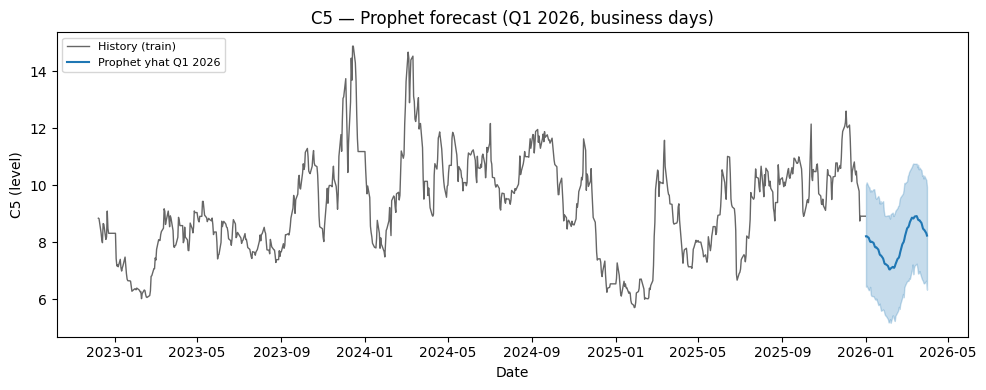

Saved: /content/drive/MyDrive/Project 005 Data/prophet_c5_q1_2026_forecast.png


,ds,yhat,yhat_lower,yhat_upper
0,2026-01-01,8.210311,6.442443,10.016791
1,2026-01-02,8.213122,6.472628,10.102951
2,2026-01-05,8.155176,6.316971,9.944578
3,2026-01-06,8.091231,6.331738,9.925844
4,2026-01-07,8.023072,6.432406,9.784382



Q1 2026 yhat summary:
count    64.000000
mean      7.969931
std       0.604018
min       7.047346
25%       7.434698
50%       7.994289
75%       8.499801
max       8.919224
Name: yhat, dtype: float64


In [ ]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(df_fit)

q1_start = pd.Timestamp(Q1_START)
q1_end = pd.Timestamp(Q1_END)
future_dates = pd.bdate_range(q1_start, q1_end, freq="B")
future = pd.DataFrame({"ds": future_dates})
fc = m.predict(future)

if USE_LOG:
    for col in ("yhat", "yhat_lower", "yhat_upper"):
        fc[col] = np.exp(fc[col])

out = fc[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
out_csv = base_dir / OUT_CSV
out.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

from IPython.display import display
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
hist_plot = df_fit.tail(min(800, len(df_fit)))
ax.plot(hist_plot["ds"], np.exp(hist_plot["y"]) if USE_LOG else hist_plot["y"], color="0.4", lw=1, label="History (train)")
ax.plot(out["ds"], out["yhat"], color="C0", lw=1.5, label="Prophet yhat Q1 2026")
ax.fill_between(out["ds"].values, out["yhat_lower"].values, out["yhat_upper"].values, alpha=0.25, color="C0")
ax.set_title("C5 — Prophet forecast (Q1 2026, business days)")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel("Date")
ax.set_ylabel("C5 (level)")
fig.tight_layout()
png_path = base_dir / OUT_PNG
fig.savefig(png_path, dpi=120)
plt.show()
print(f"Saved: {png_path}")

display(out.head())
print("\nQ1 2026 yhat summary:")
print(out["yhat"].describe())

Actuals workbook: /content/drive/MyDrive/Project 005 Data/C5 Through End Q126.xlsx
Overlap days (Q1 2026-01-01–2026-03-31): 62
MAE:  1.7645
RMSE: 2.1094
MAPE: 16.92%
Saved: /content/drive/MyDrive/Project 005 Data/prophet_c5_q1_2026_vs_Q126.csv


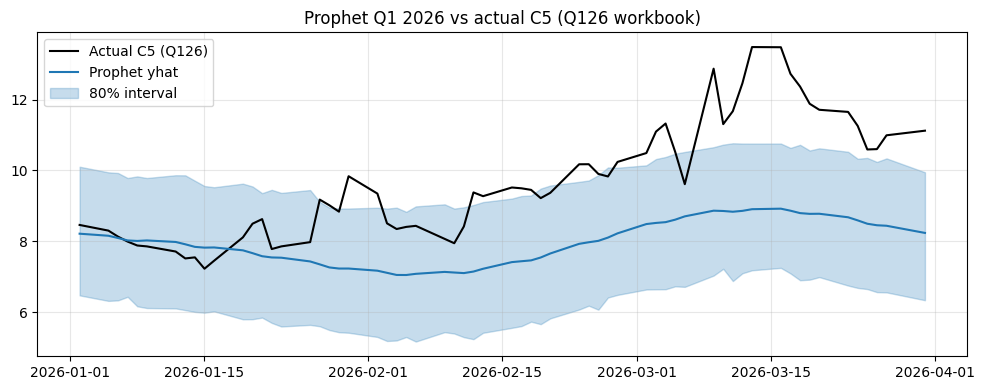

Saved: /content/drive/MyDrive/Project 005 Data/prophet_c5_q1_2026_vs_Q126.png


In [ ]:
import matplotlib.pyplot as plt

try:
    actual_s, actual_path = load_c5_actuals_q126(
        base_dir,
        ACTUAL_SHEET,
        ACTUAL_DATE_COL,
        ACTUAL_C5_COL,
        ACTUAL_XLSX,
    )
    print(f"Actuals workbook: {actual_path}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"{e}\nPlace 'C5 Through End Q126.xlsx' in {base_dir} or set PROPHET_ACTUAL_XLSX."
    ) from e

q1_start = pd.Timestamp(Q1_START)
q1_end = pd.Timestamp(Q1_END)

fc_cmp = out.copy()
fc_cmp["ds"] = pd.to_datetime(fc_cmp["ds"]).dt.normalize()

act_df = pd.DataFrame({"ds": actual_s.index, "c5_actual": actual_s.values})
act_df["ds"] = pd.to_datetime(act_df["ds"]).dt.normalize()

merged = fc_cmp.merge(act_df, on="ds", how="inner")
merged = merged[(merged["ds"] >= q1_start) & (merged["ds"] <= q1_end)].sort_values("ds")

n = len(merged)
if n == 0:
    print("No overlapping dates between Prophet forecast and Q126 actuals in the Q1 window.")
else:
    merged["error"] = merged["yhat"] - merged["c5_actual"]
    merged["abs_error"] = merged["error"].abs()
    mae = float(merged["abs_error"].mean())
    rmse = float((merged["error"] ** 2).mean() ** 0.5)
    mape = float((merged["abs_error"] / merged["c5_actual"]).mean() * 100)

    print(f"Overlap days (Q1 {q1_start.date()}–{q1_end.date()}): {n}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

    cmp_csv = base_dir / COMPARE_OUT_CSV
    merged.to_csv(cmp_csv, index=False)
    print(f"Saved: {cmp_csv}")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(merged["ds"], merged["c5_actual"], label="Actual C5 (Q126)", color="black", linewidth=1.5)
    ax.plot(merged["ds"], merged["yhat"], label="Prophet yhat", color="tab:blue")
    if {"yhat_lower", "yhat_upper"}.issubset(merged.columns):
        ax.fill_between(
            merged["ds"],
            merged["yhat_lower"],
            merged["yhat_upper"],
            alpha=0.25,
            color="tab:blue",
            label="80% interval",
        )
    ax.legend()
    ax.set_title("Prophet Q1 2026 vs actual C5 (Q126 workbook)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    cmp_png = base_dir / COMPARE_OUT_PNG
    fig.savefig(cmp_png, dpi=150)
    plt.show()
    print(f"Saved: {cmp_png}")

## Part 4 — Prophet with Exogenous Regressors

Extends the univariate Prophet model by adding the **top-K lagged covariates**
from the master lagged workbook as `add_regressor()` terms.

**Why this helps:** regressors anchor the *level and magnitude* of the forecast
to real commodity signals (Brent, China PMI, iron ore, etc.) rather than letting
Prophet rely on trend + seasonality alone.

**Future regressor values:** since the regressors are lagged (e.g. `lag_63` =
value 63 business days ago), they are already known at forecast time — no
forward-looking leakage. Remaining unavailable values are forward-filled from
the last known date.

Config knobs (in Cell 1 / `PROPHET_REG_*`):
- `PROPHET_REG_TOP_K` — how many regressors to add (default 5)
- `PROPHET_REG_PRIOR_SCALE` — regularisation; lower = regressors matter less
- `PROPHET_REG_STANDARDIZE` — whether Prophet standardises each regressor

In [ ]:
# ── Part 4 config (add to Cell 1 if you want persistent overrides) ───────────
PROPHET_REG_TOP_K        = 5      # number of lagged regressors to add
PROPHET_REG_PRIOR_SCALE  = 0.1    # Prophet regressor prior scale (lower = more regularised)
PROPHET_REG_STANDARDIZE  = True   # standardise regressors inside Prophet
PROPHET_REG_OUT_CSV      = "prophet_reg_c5_q1_2026_forecast.csv"
PROPHET_REG_COMPARE_CSV  = "prophet_reg_c5_q1_2026_vs_Q126.csv"
PROPHET_REG_OUT_PNG      = "prophet_reg_c5_q1_2026_forecast.png"

# Lagged workbook (same as Chronos-2 notebook)
import os
_master_lagged_cands = [
    os.environ.get("XGBOOST_MASTER_LAGGED_XLSX"),
    "Moving_Average_Features_Lagged__from_Master_Data_AVG_version_update.xlsx",
    "Master_Data_AVG_version_update_Lagged.xlsx",
]
PROPHET_LAGGED_XLSX = _first_existing(_master_lagged_cands, base_dir)
if PROPHET_LAGGED_XLSX is None:
    print("WARNING: Master lagged workbook not found — Part 4 will skip.")
    print(f"  Searched in: {base_dir}")
else:
    print(f"Lagged workbook: {PROPHET_LAGGED_XLSX.name}")

Lagged workbook: Master_Data_AVG_version_update_Lagged.xlsx


Loading lagged features...
  Lagged features: 358 columns | 2005-12-09 → 2026-12-31

  Top-5 regressors by |corr| with C5:
    C5_ma_63                                                           |corr|=0.8338
    1_Month_FFA_Route_Average_ma_63                                    |corr|=0.8297
    2_Month_FFA_Route_Average_ma_63                                    |corr|=0.8226
    3_Month_FFA_Route_Average_lag_1                                    |corr|=0.8193
    C3_1_Mon_FFA_ma_63                                                 |corr|=0.8036

  Training rows after regressor merge: 2870

  Fitting Prophet with regressors...
  Done.
  Saved: prophet_reg_c5_q1_2026_forecast.csv

  Q1 2026 vs actuals (n=62):
    MAE  = 1.3799
    RMSE = 1.5189
    R²   = 0.1458


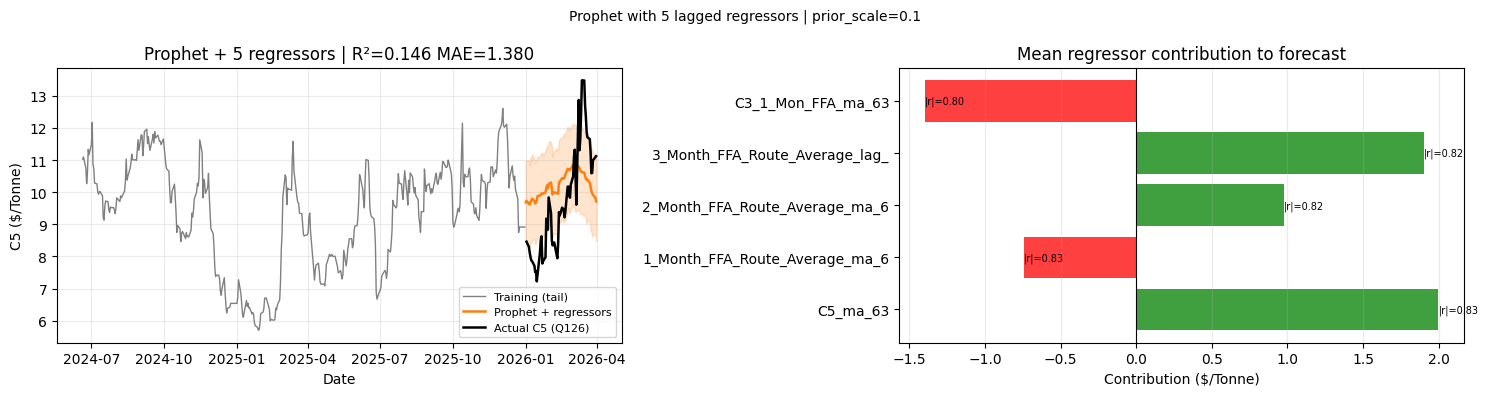

  Saved: prophet_reg_c5_q1_2026_forecast.png


,ds,yhat,yhat_lower,yhat_upper
0,2026-01-01,9.684901,8.484623,10.969038
1,2026-01-02,9.730724,8.386120,10.979878
2,2026-01-05,9.640028,8.372067,10.995355
3,2026-01-06,9.626260,8.278780,10.840738
4,2026-01-07,9.696678,8.416990,11.089738
5,2026-01-08,9.729939,8.437742,10.949919
6,2026-01-09,9.798793,8.513826,11.176572
7,2026-01-12,9.730086,8.536824,11.030574
8,2026-01-13,9.648795,8.372198,10.910913
9,2026-01-14,9.679288,8.432043,10.966611



Q1 2026 yhat (Prophet + regressors) summary:
count    64.000000
mean     10.206862
std       0.380010
min       9.626260
25%       9.916038
50%      10.146072
75%      10.554053
max      10.852191
Name: yhat, dtype: float64


In [ ]:
# ── Part 4: Prophet + lagged regressors ──────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

if PROPHET_LAGGED_XLSX is None:
    print("Part 4 skipped — PROPHET_LAGGED_XLSX not found.")
else:
    # ── 1. Load master lagged workbook ────────────────────────────────────────
    print("Loading lagged features...")
    _lag_raw = pd.read_excel(PROPHET_LAGGED_XLSX, sheet_name=0, index_col=0)
    _lag_raw.index = pd.to_datetime(_lag_raw.index, errors="coerce")
    _lag_raw = _lag_raw[_lag_raw.index.notna()].sort_index()

    # Drop model-generated columns
    _drop_pat = ("XGBoost_pred", "_pred")
    _lag_raw = _lag_raw.drop(
        columns=[c for c in _lag_raw.columns if any(p in str(c) for p in _drop_pat)],
        errors="ignore"
    )
    # Sanitise column names for Prophet (no spaces or special chars)
    import re
    _safe_map = {
        c: re.sub(r"[^\w]+", "_", str(c)).strip("_")[:80]
        for c in _lag_raw.columns
    }
    # Ensure uniqueness
    _seen_counts = {}
    for orig in list(_safe_map.keys()):
        safe = _safe_map[orig]
        if safe in _seen_counts:
            _seen_counts[safe] += 1
            _safe_map[orig] = f"{safe}_{_seen_counts[safe]}"
        else:
            _seen_counts[safe] = 0
    _lag_safe = _lag_raw.rename(columns=_safe_map)
    print(f"  Lagged features: {_lag_safe.shape[1]} columns | "
          f"{_lag_safe.index.min().date()} → {_lag_safe.index.max().date()}")

    # ── 2. Select top-K regressors by |corr| with C5 ─────────────────────────
    # Align lag frame with training C5 to compute correlations
    _c5_tr = pd.Series(
        c5.loc[(c5.index >= pd.Timestamp(TRAIN_START)) &
               (c5.index <= pd.Timestamp(TRAIN_END))].values,
        index=pd.to_datetime(
            c5.loc[(c5.index >= pd.Timestamp(TRAIN_START)) &
                   (c5.index <= pd.Timestamp(TRAIN_END))].index
        )
    )
    _lag_aligned = _lag_safe.reindex(_c5_tr.index).ffill().bfill()
    _valid_cols = [
        c for c in _lag_aligned.columns
        if _lag_aligned[c].notna().sum() > 30
    ]
    _corr = (
        _lag_aligned[_valid_cols]
        .corrwith(_c5_tr)
        .abs()
        .dropna()
        .sort_values(ascending=False)
    )
    _top_reg_cols = _corr.head(PROPHET_REG_TOP_K).index.tolist()
    print(f"\n  Top-{PROPHET_REG_TOP_K} regressors by |corr| with C5:")
    for _rc in _top_reg_cols:
        print(f"    {_rc[:65]:65s}  |corr|={_corr[_rc]:.4f}")

    # ── 3. Build Prophet training dataframe with regressors ───────────────────
    _df_reg = df_fit.copy()
    _df_reg["ds"] = pd.to_datetime(_df_reg["ds"])
    for _rc in _top_reg_cols:
        _rc_ser = _lag_safe[_rc].reindex(_df_reg["ds"]).ffill().bfill()
        _df_reg[_rc] = _rc_ser.values
    _df_reg = _df_reg.dropna(subset=_top_reg_cols)
    print(f"\n  Training rows after regressor merge: {len(_df_reg)}")

    # ── 4. Build future dataframe with regressor values ───────────────────────
    _q1_start = pd.Timestamp(Q1_START)
    _q1_end   = pd.Timestamp(Q1_END)
    _future_dates = pd.bdate_range(_q1_start, _q1_end, freq="B")
    _future_reg = pd.DataFrame({"ds": _future_dates})
    _future_reg["ds"] = pd.to_datetime(_future_reg["ds"])
    for _rc in _top_reg_cols:
        # Use lagged feature values in forecast window (already known due to lag structure)
        # Fall back to ffill from last training value for any gaps
        _rc_fut = _lag_safe[_rc].reindex(_future_reg["ds"])
        _last_known = float(_lag_safe[_rc].dropna().iloc[-1])
        _rc_fut = _rc_fut.fillna(_last_known)
        _future_reg[_rc] = _rc_fut.values
    _n_missing = _future_reg[_top_reg_cols].isna().sum().sum()
    if _n_missing > 0:
        _future_reg[_top_reg_cols] = _future_reg[_top_reg_cols].ffill().bfill()
        print(f"  Note: {_n_missing} missing future regressor values forward-filled")

    # ── 5. Fit Prophet with regressors ────────────────────────────────────────
    print("\n  Fitting Prophet with regressors...")
    from prophet import Prophet
    _m_reg = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
    )
    for _rc in _top_reg_cols:
        _m_reg.add_regressor(
            _rc,
            prior_scale=PROPHET_REG_PRIOR_SCALE,
            standardize=PROPHET_REG_STANDARDIZE,
        )
    _m_reg.fit(_df_reg)
    print("  Done.")

    # ── 6. Forecast ───────────────────────────────────────────────────────────
    _fc_reg = _m_reg.predict(_future_reg)
    if USE_LOG:
        for _col in ("yhat", "yhat_lower", "yhat_upper"):
            _fc_reg[_col] = np.exp(_fc_reg[_col])

    _out_reg = _fc_reg[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
    _out_reg_csv = base_dir / PROPHET_REG_OUT_CSV
    _out_reg.to_csv(_out_reg_csv, index=False)
    print(f"  Saved: {_out_reg_csv.name}")

    # ── 7. Compare to actuals ─────────────────────────────────────────────────
    try:
        _act_s, _ = load_c5_actuals_q126(
            base_dir, ACTUAL_SHEET, ACTUAL_DATE_COL, ACTUAL_C5_COL, ACTUAL_XLSX
        )
        _act_df = pd.DataFrame({"ds": _act_s.index, "c5_actual": _act_s.values})
        _act_df["ds"] = pd.to_datetime(_act_df["ds"]).dt.normalize()
        _merged_reg = _out_reg.copy()
        _merged_reg["ds"] = pd.to_datetime(_merged_reg["ds"]).dt.normalize()
        _merged_reg = (
            _merged_reg.merge(_act_df, on="ds", how="inner")
            .pipe(lambda d: d[(d["ds"] >= _q1_start) & (d["ds"] <= _q1_end)])
            .sort_values("ds")
        )
        if len(_merged_reg) > 0:
            from sklearn.metrics import r2_score
            _err    = _merged_reg["yhat"] - _merged_reg["c5_actual"]
            _mae_r  = float(_err.abs().mean())
            _rmse_r = float((_err**2).mean()**0.5)
            _r2_r   = float(r2_score(_merged_reg["c5_actual"], _merged_reg["yhat"]))
            print(f"\n  Q1 2026 vs actuals (n={len(_merged_reg)}):")
            print(f"    MAE  = {_mae_r:.4f}")
            print(f"    RMSE = {_rmse_r:.4f}")
            print(f"    R²   = {_r2_r:.4f}")
            _merged_reg.to_csv(base_dir / PROPHET_REG_COMPARE_CSV, index=False)
    except FileNotFoundError:
        _merged_reg = pd.DataFrame()
        print("  Actuals file not found — skipping comparison metrics.")

    # ── 8. Plot ───────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Left: full forecast vs actuals
    ax = axes[0]
    _hist_tail = _df_reg.tail(min(400, len(_df_reg)))
    _hist_y = np.exp(_hist_tail["y"]) if USE_LOG else _hist_tail["y"]
    ax.plot(_hist_tail["ds"], _hist_y, color="0.5", lw=1.0, label="Training (tail)")
    ax.plot(_out_reg["ds"], _out_reg["yhat"],
            color="tab:orange", lw=1.8, label="Prophet + regressors")
    ax.fill_between(_out_reg["ds"], _out_reg["yhat_lower"], _out_reg["yhat_upper"],
                    alpha=0.20, color="tab:orange")
    if len(_merged_reg) > 0:
        ax.plot(_merged_reg["ds"], _merged_reg["c5_actual"],
                color="black", lw=1.8, label="Actual C5 (Q126)")
        ax.set_title(f"Prophet + {PROPHET_REG_TOP_K} regressors | "
                     f"R²={_r2_r:.3f} MAE={_mae_r:.3f}")
    else:
        ax.set_title(f"Prophet + {PROPHET_REG_TOP_K} regressors | Q1 2026 forecast")
    ax.legend(fontsize=8); ax.set_xlabel("Date"); ax.set_ylabel("C5 ($/Tonne)")
    ax.grid(alpha=0.25)

    # Right: regressor coefficient plot (component sizes)
    ax2 = axes[1]
    # Extract regressor contributions from Prophet components
    try:
        _comp = _m_reg.predict(_future_reg)
        _reg_contribs = {_rc: float(_comp[_rc].mean()) for _rc in _top_reg_cols}
        _reg_corrs    = {_rc: float(_corr[_rc]) for _rc in _top_reg_cols}
        _colors = ["green" if v >= 0 else "red" for v in _reg_contribs.values()]
        _short_names  = [r[:30] for r in _top_reg_cols]
        _bars = ax2.barh(_short_names, list(_reg_contribs.values()),
                         color=_colors, alpha=0.75)
        ax2.axvline(0, color="black", lw=0.8)
        ax2.set_title("Mean regressor contribution to forecast")
        ax2.set_xlabel("Contribution to yhat (log scale)" if USE_LOG else "Contribution ($/Tonne)")
        ax2.grid(alpha=0.25, axis="x")
        # Add |corr| annotation
        for _i, (_bar, _rc) in enumerate(zip(_bars, _top_reg_cols)):
            ax2.text(_bar.get_width() + 0.001,
                     _bar.get_y() + _bar.get_height()/2,
                     f"|r|={_corr[_rc]:.2f}", va="center", fontsize=7)
    except Exception as _ce:
        ax2.text(0.5, 0.5, f"Component plot failed:\n{_ce}",
                 ha="center", va="center", transform=ax2.transAxes, fontsize=8)

    plt.suptitle(
        f"Prophet with {PROPHET_REG_TOP_K} lagged regressors | "
        f"prior_scale={PROPHET_REG_PRIOR_SCALE}",
        fontsize=10
    )
    plt.tight_layout()
    _png = base_dir / PROPHET_REG_OUT_PNG
    plt.savefig(_png, dpi=120)
    plt.show()
    print(f"  Saved: {_png.name}")

    from IPython.display import display
    display(_out_reg.head(10))
    print("\nQ1 2026 yhat (Prophet + regressors) summary:")
    print(_out_reg["yhat"].describe())

## Part 3 — NeuralProphet

Uses the same **`df_fit`** as Prophet (`ds`, `y`), including **`USE_LOG`** behavior. Fits with **`freq='B'`** (business days).

The constructor matches your specification (`n_lags`, `n_forecasts=60`, AR MLP, changepoints, **standardize** normalization, yearly + weekly seasonality). The **forecast horizon is 60 business steps** after the last training date (`make_future_dataframe(..., periods=60)`), not the full Q1 row count when that exceeds 60.

Requires **`pip install neuralprophet`**. On **Python 3.13**, install often fails because NeuralProphet pins **NumPy &lt; 2** (no usable wheel + pip tries to compile NumPy). Use a **3.11 / 3.12** environment (see notebook title cell).

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
INFO - (NP.config.__post_init__) - Note: Trend changepoint regularization is experimental.
INFO:NP.config:Note: Trend changepoint regularization is experimental.
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.965% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 99.965% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO:NP.utils:Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.


Fitting NeuralProphet (first run — will save model for future reproduction)...


INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64
INFO:NP.config:Auto-set batch_size to 64


Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.965% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 99.965% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 62.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.18% of the data.
INFO:NP.df_utils:Major frequency B corresponds to 99.18% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - B
INFO:NP.df_utils:Defined frequency is equal to major frequency - B
INFO - (NP.df_utils._infer_frequency) - Major frequency B corresponds to 99.18% of the data.
INFO:NP.df_

  Save failed ('NeuralProphet' object has no attribute 'save') — refit will occur on next run.


Predicting: 43it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


NeuralProphet prediction column used: 'origin-0'
Level correction applied: +0.1832 (last actual=8.9150, first yhat=8.7318)
  Level offset: +0.0000
  Slope alpha:  0.7 (1.0 = no dampening, 0.0 = flat)
Saved: /content/drive/MyDrive/Project 005 Data/neuralprophet_c5_forecast.csv


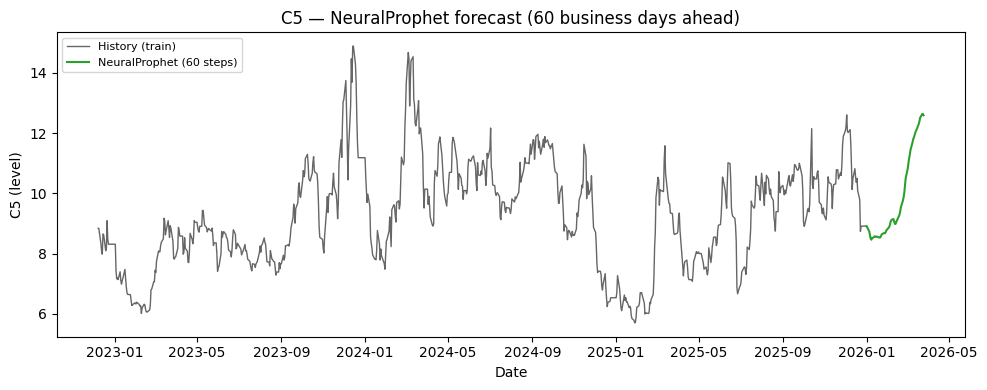

Saved: /content/drive/MyDrive/Project 005 Data/neuralprophet_c5_forecast.png


,ds,yhat
0,2026-01-01,8.915
1,2026-01-02,8.870484
2,2026-01-05,8.734422
3,2026-01-06,8.597601
4,2026-01-07,8.495121



NeuralProphet yhat summary:
count     60.000
unique    60.000
top        8.915
freq       1.000
Name: yhat, dtype: float64


In [ ]:
import sys

if sys.version_info >= (3, 13):
    print(
        "Note: PyPI neuralprophet pins numpy<2. On Python 3.13, `pip install neuralprophet` may try to "
        "build NumPy from source (Meson) and fail. Use a Python 3.11/3.12 kernel, or see the title cell.\n"
    )

try:
    from neuralprophet import NeuralProphet
except ImportError as e:
    raise ImportError(
        "Install NeuralProphet: pip install neuralprophet  (if that errors on py3.13, switch to python=3.12; "
        "see notebook intro.)"
    ) from e
except Exception as e:
    err = str(e).lower()
    msg = type(e).__name__.lower()
    if (
        "contextualversionconflict" in msg
        or "contextualversionconflict" in err
        or "torchvision::nms" in err
        or "nms does not exist" in err
    ):
        raise RuntimeError(
            "PyTorch / Lightning stack mismatch. neuralprophet 0.8 needs pytorch-lightning 1.x (<2). "
            "Reinstall aligned torch+torchvision and pytorch-lightning==1.9.5 — see title cell "
            "`pip install ... pytorch-lightning==1.9.5 neuralprophet`."
        ) from e
    raise

from IPython.display import display


def _np_pick_yhat(df_fc: pd.DataFrame) -> tuple[pd.Series, str]:
    """Pick the main prediction column from a NeuralProphet forecast df."""
    for c in ("yhat", "Yhat"):
        if c in df_fc.columns:
            return df_fc[c], c
    for c in df_fc.columns:
        if isinstance(c, str) and c.replace(" ", "").lower() == "origin-0":
            return df_fc[c], c
        if isinstance(c, str) and c.startswith("origin"):
            return df_fc[c], c
    numeric_yhat = sorted(
        [c for c in df_fc.columns if isinstance(c, str) and c.startswith("yhat")],
        key=lambda x: int("".join(filter(str.isdigit, x.replace("yhat", ""))) or "0"),
    )
    if numeric_yhat:
        return df_fc[numeric_yhat[-1]], numeric_yhat[-1]
    raise KeyError(f"No yhat-like column found; columns={list(df_fc.columns)[:25]}...")


df_np = df_fit.copy()


# ── Reproducibility: fix all random seeds before fitting ─────────────────────
import random as _random_np
_NP_SEED = 42
_random_np.seed(_NP_SEED)
np.random.seed(_NP_SEED)
try:
    import torch as _torch_np
    _torch_np.manual_seed(_NP_SEED)
    if _torch_np.cuda.is_available():
        _torch_np.cuda.manual_seed_all(_NP_SEED)
        _torch_np.backends.cudnn.deterministic = True
        _torch_np.backends.cudnn.benchmark = False
except Exception:
    pass

# ── Save/load model to guarantee identical output on re-runs ─────────────────
# On first run: fits the model and saves weights to disk.
# On subsequent runs: loads saved weights instead of refitting (exact reproduction).
# Delete neuralprophet_model_part3.pkl to force a refit.
_NP_MODEL_FILE = base_dir / "neuralprophet_model_part3.pkl"

m_np = NeuralProphet(
    n_lags=60,
    n_forecasts=62,
    ar_layers=[64],
    n_changepoints=40,
    changepoints_range=0.98,
    trend_reg=0.005,
    learning_rate=0.005,
    normalize="minmax",
    global_normalization=True,
    epochs=700,
)

if _NP_MODEL_FILE.is_file():
    print(f"Loading saved NeuralProphet model: {_NP_MODEL_FILE.name}")
    m_np = m_np.restore(_NP_MODEL_FILE.__str__()) if hasattr(m_np, "restore") else m_np
    try:
        from neuralprophet import load as _np_load
        m_np = _np_load(_NP_MODEL_FILE.__str__())
        print("  Model loaded successfully — skipping refit.")
    except Exception as _e:
        print(f"  Load failed ({_e}) — refitting from scratch.")
        metrics_np = m_np.fit(df_np, freq="B")
        m_np.save(_NP_MODEL_FILE.__str__())
        print(f"  Model saved: {_NP_MODEL_FILE.name}")
else:
    print("Fitting NeuralProphet (first run — will save model for future reproduction)...")
    metrics_np = m_np.fit(df_np, freq="B")
    try:
        m_np.save(_NP_MODEL_FILE.__str__())
        print(f"  Model saved: {_NP_MODEL_FILE.name} — future runs will load this exactly.")
    except Exception as _e:
        print(f"  Save failed ({_e}) — refit will occur on next run.")

future_np = m_np.make_future_dataframe(df_np, periods=60, n_historic_predictions=False)
fc_np = m_np.predict(future_np)

try:
    lf = m_np.get_latest_forecast(fc_np, include_history_data=False)
    lf_f = lf[lf["ds"] > pd.to_datetime(df_np["ds"]).max()].sort_values("ds").head(60)
    yhat_s, yhat_name = _np_pick_yhat(lf_f)
    out_np = pd.DataFrame({"ds": lf_f["ds"].values, "yhat": yhat_s.values})
except Exception:
    hist_max = pd.to_datetime(df_np["ds"]).max()
    fut_only = fc_np[pd.to_datetime(fc_np["ds"]) > hist_max].sort_values("ds").head(60)
    yhat_s, yhat_name = _np_pick_yhat(fut_only)
    out_np = pd.DataFrame({"ds": fut_only["ds"].values, "yhat": yhat_s.values})

print(f"NeuralProphet prediction column used: {yhat_name!r}")

if USE_LOG:
    out_np["yhat"] = np.exp(out_np["yhat"])

out_np["ds"] = pd.to_datetime(out_np["ds"])
# After generating out_np["yhat"]:
_last_actual = float(c5.iloc[-1])
_first_yhat  = float(out_np["yhat"].iloc[0])
_offset      = _last_actual - _first_yhat
out_np["yhat"] = out_np["yhat"] + _offset
print(f"Level correction applied: {_offset:+.4f} (last actual={_last_actual:.4f}, first yhat={_first_yhat:.4f})")

# After generating out_np["yhat"] and applying the level anchor:
_last_actual = float(c5.iloc[-1])
_first_yhat  = float(out_np["yhat"].iloc[0])
_level_offset = _last_actual - _first_yhat
out_np["yhat"] = out_np["yhat"] + _level_offset  # level anchor first

# Slope dampening: blend forecast toward a flat line as horizon grows
# alpha=0 → fully flat (no slope), alpha=1 → original slope unchanged
SLOPE_ALPHA = 0.7   # tune between 0.4–0.8; lower = more dampened
_flat_line   = np.full(len(out_np), _last_actual)
_anchored    = out_np["yhat"].values
out_np["yhat"] = SLOPE_ALPHA * _anchored + (1 - SLOPE_ALPHA) * _flat_line
print(f"  Level offset: {_level_offset:+.4f}")
print(f"  Slope alpha:  {SLOPE_ALPHA} (1.0 = no dampening, 0.0 = flat)")

np_csv = base_dir / NEURAL_OUT_CSV
out_np.to_csv(np_csv, index=False)
print(f"Saved: {np_csv}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
hist_np = df_np.tail(min(800, len(df_np))).copy()
hist_y_plot = np.exp(hist_np["y"]) if USE_LOG else hist_np["y"]
ax.plot(hist_np["ds"], hist_y_plot, color="0.4", lw=1, label="History (train)")
ax.plot(out_np["ds"], out_np["yhat"], color="C2", lw=1.5, label="NeuralProphet (60 steps)")
ax.set_title("C5 — NeuralProphet forecast (60 business days ahead)")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel("Date")
ax.set_ylabel("C5 (level)")
fig.tight_layout()
np_png = base_dir / NEURAL_OUT_PNG
fig.savefig(np_png, dpi=120)
plt.show()
print(f"Saved: {np_png}")

display(out_np.head())
print("\nNeuralProphet yhat summary:")
print(out_np["yhat"].describe())

### NeuralProphet vs Q126 actuals

Overlaps **`out_np`** with Q126 daily actuals wherever dates align (typically early Q1 2026 within the **60-step** NeuralProphet horizon).

Actuals workbook: /content/drive/MyDrive/Project 005 Data/C5 Through End Q126.xlsx
NeuralProphet vs actual — overlap days (Q1 2026-01-01–2026-03-31): 59
MAE:  0.6225
RMSE: 0.7626
MAPE: 6.70%
Saved: /content/drive/MyDrive/Project 005 Data/neuralprophet_c5_vs_Q126.csv


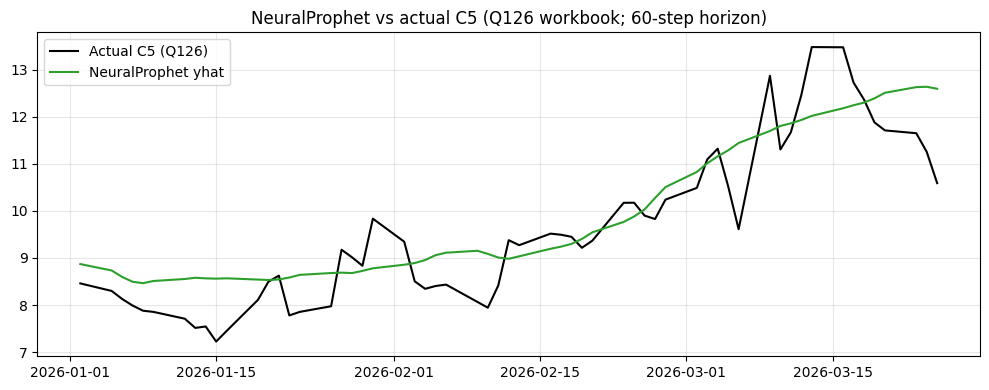

Saved: /content/drive/MyDrive/Project 005 Data/neuralprophet_c5_vs_Q126.png


In [ ]:
import matplotlib.pyplot as plt

try:
    actual_s_np, actual_path_np = load_c5_actuals_q126(
        base_dir,
        ACTUAL_SHEET,
        ACTUAL_DATE_COL,
        ACTUAL_C5_COL,
        ACTUAL_XLSX,
    )
    print(f"Actuals workbook: {actual_path_np}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"{e}\nPlace 'C5 Through End Q126.xlsx' in {base_dir} or set PROPHET_ACTUAL_XLSX."
    ) from e

q1_start = pd.Timestamp(Q1_START)
q1_end = pd.Timestamp(Q1_END)

fc_cmp_np = out_np.copy()
fc_cmp_np["ds"] = pd.to_datetime(fc_cmp_np["ds"]).dt.normalize()

act_df_np = pd.DataFrame({"ds": actual_s_np.index, "c5_actual": actual_s_np.values})
act_df_np["ds"] = pd.to_datetime(act_df_np["ds"]).dt.normalize()

merged_np = fc_cmp_np.merge(act_df_np, on="ds", how="inner")
merged_np = merged_np[(merged_np["ds"] >= q1_start) & (merged_np["ds"] <= q1_end)].sort_values("ds")

n_np = len(merged_np)
if n_np == 0:
    print("No overlapping dates between NeuralProphet forecast and Q126 actuals in the Q1 window.")
else:
    merged_np["error"] = merged_np["yhat"] - merged_np["c5_actual"]
    merged_np["abs_error"] = merged_np["error"].abs()
    mae_np = float(merged_np["abs_error"].mean())
    rmse_np = float((merged_np["error"] ** 2).mean() ** 0.5)
    mape_np = float((merged_np["abs_error"] / merged_np["c5_actual"]).mean() * 100)

    print(f"NeuralProphet vs actual — overlap days (Q1 {q1_start.date()}–{q1_end.date()}): {n_np}")
    print(f"MAE:  {mae_np:.4f}")
    print(f"RMSE: {rmse_np:.4f}")
    print(f"MAPE: {mape_np:.2f}%")

    cmp_csv_np = base_dir / NEURAL_COMPARE_OUT_CSV
    merged_np.to_csv(cmp_csv_np, index=False)
    print(f"Saved: {cmp_csv_np}")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(merged_np["ds"], merged_np["c5_actual"], label="Actual C5 (Q126)", color="black", linewidth=1.5)
    ax.plot(merged_np["ds"], merged_np["yhat"], label="NeuralProphet yhat", color="tab:green")
    ax.legend()
    ax.set_title("NeuralProphet vs actual C5 (Q126 workbook; 60-step horizon)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    cmp_png_np = base_dir / NEURAL_COMPARE_OUT_PNG
    fig.savefig(cmp_png_np, dpi=150)
    plt.show()
    print(f"Saved: {cmp_png_np}")